In [1]:
import json

import collections
from ortools.sat.python import cp_model

In [2]:
import resource
import tracemalloc
from functools import wraps

def peak_mem(fn):
    @wraps(fn)
    def wrapper(*args, **kwargs):
        rss_before = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
        tracemalloc.start()
        try:
            return fn(*args, **kwargs)
        finally:
            _, peak = tracemalloc.get_traced_memory()
            tracemalloc.stop()
            rss_after = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
            print(
                f"{fn.__name__}: "
                f"tracemalloc peak={peak / 1e6:.1f} MB, "
                f"RSS max={rss_after / 1024:.1f} MB "
                f"(was {rss_before / 1024:.1f} MB)"
            )
    return wrapper

In [3]:
with open("../data/animal_rollouts.json", "r") as f:
    data = json.load(f)

# print(data)

In [4]:
NUM_DAYS = data["meta"]["horizon_days"]
NUM_TILES = 9

PROFILE = "no_care"
WHEAT_PRICE = 25
SETUP_OP_OVERHEAD = 1
animals = {k: v[PROFILE] for k, v in data["animals"].items()}

elements = []
for tile in range(NUM_TILES):
    for day in range(NUM_DAYS):
        elements.append((tile, day))

subsets = []
for animal, profile in animals.items():
    animal_cost = data["animals"][animal]["animal_cost"]
    base_price = data["animals"][animal]["base_price"]

    for el in elements:
        place_day = el[1]
        subset = {
            "id": f"S{len(subsets)}",
            "animal": animal,
            "tile": el[0],
            "day": place_day,
            "subset": set(),
            "weight": 0,
        }

        for age_day in profile["days"]:
            day_coord = place_day + age_day["age"]
            if day_coord < NUM_DAYS:
                subset["subset"].add((el[0], day_coord))
            else:
                break

        if not subset["subset"]:
            continue

        rev = sum(
            y * base_price
            for age, y in zip(profile["harvest_ages"], profile["yield_per_harvest"])
            if place_day + age < NUM_DAYS
        )
        feed_days = len(subset["subset"])
        subset["weight"] = rev - animal_cost - feed_days * WHEAT_PRICE
        subsets.append(subset)

ops_count = {}
for animal, profile in animals.items():
    ops_count.setdefault(animal, {})
    for day in profile["days"]:
        ops_count[animal][day["age"]] = len(day["actions"])

In [5]:
# Declare the model
model = cp_model.CpModel()

In [6]:
# Define the variables - one binary decision var per candidate subset
y = {s["id"]: model.NewBoolVar(s["id"]) for s in subsets}

In [7]:
# Packing constraint: each element covered by at most one selected subset
for e in elements:
    covering = [y[s["id"]] for s in subsets if e in s["subset"]]
    if covering:
        model.Add(sum(covering) <= 1)

In [8]:
# Daily limit on the operations: 16 is the max number of operations per day
for day in range(NUM_DAYS):
    operations = []
    for s in subsets:
        subset_days = {e[1] for e in s["subset"]}
        if day in subset_days:
            age = day - s["day"]
            n_ops = ops_count[s["animal"]][age]
            if age == 0:
                n_ops += SETUP_OP_OVERHEAD
            operations.append(y[s["id"]] * n_ops)

    if day == 0:
        model.Add(sum(operations) <= 15)  # first day also has BUY_* market turn
    else:
        model.Add(sum(operations) <= 16)

In [9]:
# Objective: maximize the total expected profit
model.Maximize(sum(s["weight"] * y[s["id"]] for s in subsets))

In [10]:
@peak_mem
def run(_solver):
    return _solver.Solve(model)

solver = cp_model.CpSolver()
status = run(solver)

print(status, solver.StatusName(status))
print("objective:", solver.ObjectiveValue())

run: tracemalloc peak=0.0 MB, RSS max=158.1 MB (was 141.6 MB)
CpSolverStatus.OPTIMAL OPTIMAL
objective: 5665.0


In [11]:
selected = [s for s in subsets if solver.Value(y[s["id"]]) == 1]
print("n selected:", len(selected))
for s in selected:
    print(f"  {s['animal']:5} tile={s['tile']} place_day={s['day']} weight={s['weight']:.0f}")

daily_ops = [0] * NUM_DAYS
for s in selected:
    for day in range(NUM_DAYS):
        if day in {e[1] for e in s["subset"]}:
            age = day - s["day"]
            n_ops = ops_count[s["animal"]][age]
            if age == 0:
                n_ops += SETUP_OP_OVERHEAD
            daily_ops[day] += n_ops
print("peak ops/day:", max(daily_ops), "  day 0:", daily_ops[0])

n selected: 9


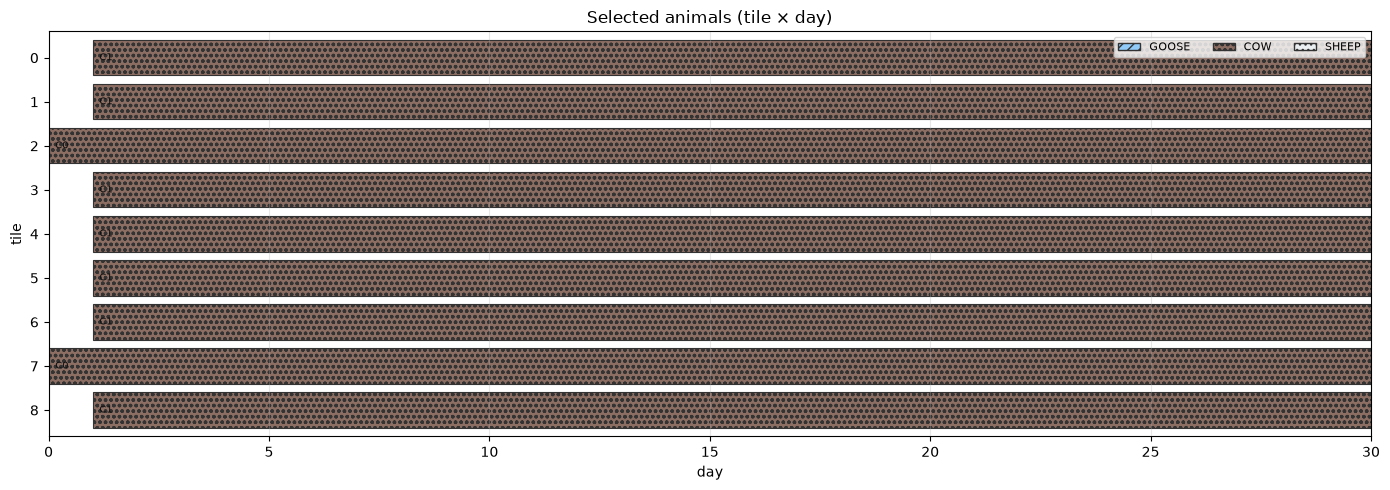

In [12]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

ANIMAL_STYLE = {
    "GOOSE": {"color": "#90caf9", "hatch": "///"},
    "COW": {"color": "#8d6e63", "hatch": "ooo"},
    "SHEEP": {"color": "#eceff1", "hatch": "..."},
}

fig, ax = plt.subplots(figsize=(14, 5))
for s in selected:
    days = sorted(d for _, d in s["subset"])
    start, end = days[0], days[-1] + 1
    style = ANIMAL_STYLE.get(s["animal"], {"color": "#999999", "hatch": ""})
    ax.barh(
        y=s["tile"],
        width=end - start,
        left=start,
        height=0.8,
        color=style["color"],
        hatch=style["hatch"],
        edgecolor="#333333",
        linewidth=0.8,
    )
    label = f"{s['animal'][:1]}{s['day']}"
    ax.text(start + 0.15, s["tile"], label, va="center", fontsize=7, color="#111")

ax.set_xlabel("day")
ax.set_ylabel("tile")
ax.set_yticks(range(NUM_TILES))
ax.set_xlim(0, NUM_DAYS)
ax.set_ylim(-0.6, NUM_TILES - 0.4)
ax.set_title("Selected animals (tile × day)")
ax.invert_yaxis()
ax.legend(
    handles=[
        Patch(facecolor=st["color"], hatch=st["hatch"], edgecolor="#333333", label=name)
        for name, st in ANIMAL_STYLE.items()
    ],
    loc="upper right",
    ncol=len(ANIMAL_STYLE),
    fontsize=8,
)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()